In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

## Create data

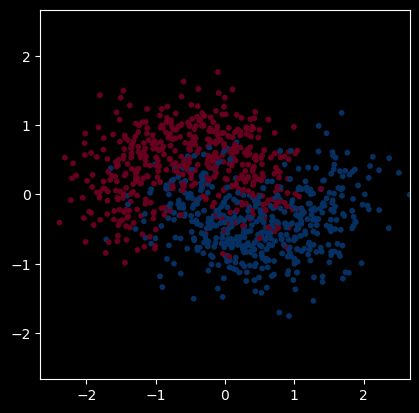

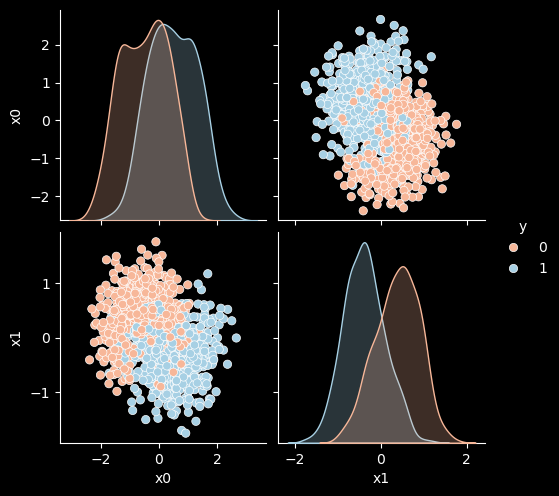

In [7]:
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles

n_samples = 1000

choice = 2

if   choice == 0:
    X, y = make_blobs(
        n_samples=n_samples,
        n_features=2,
        centers=2,
        cluster_std=7,
        random_state=10
    )
elif choice == 1:
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        n_classes=2,
        #random_state=41
    )
elif choice == 2:
    X, y = make_moons(
        n_samples=n_samples,
        noise=0.4,
        random_state=42
    )
elif choice == 3:
    X, y = make_circles(
        n_samples=n_samples,
        noise=0.1,
        factor=0.5,
        random_state=42
    )
# end

X = X - X.mean(axis=0)

MAX = np.max(np.abs(X))

plt.style.use('dark_background')

plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap="RdBu");
plt.xlim(-MAX,MAX)
plt.ylim(-MAX,MAX)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## Modeling

With our classification dataset ready, we now explore how three types of models perform across a range of complexity settings.

Instead of picking a single configuration and evaluating it, we perform a **parameter sweep**: for each model, we vary one key hyperparameter across every integer value in a meaningful range and record how performance changes on both the training and test sets.

This approach makes the **bias-variance tradeoff** visible:

- **High bias (underfitting):** Both train and test accuracy are low — the model is too simple to capture the underlying pattern.
- **High variance (overfitting):** Train accuracy is high but test accuracy lags behind — the model has memorized training data rather than learned the general pattern.
- **The sweet spot:** The parameter value where test performance peaks before it plateaus or degrades.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Metrics

For each parameter setting we compute four classification metrics on both the training and test splits:

| Metric | What it measures |
|--------|-----------------|
| **Accuracy** | Overall fraction of correct predictions |
| **Precision** | Of all predicted positives, what fraction are truly positive |
| **Recall** | Of all actual positives, what fraction did we correctly identify |
| **F1 Score** | Harmonic mean of precision and recall — balances both |

All three of precision, recall, and F1 are computed with `average='weighted'`, which accounts for class imbalance and works for both binary and multi-class datasets.

A **large gap between the train and test curves** signals overfitting. When both curves are low, the model is underfitting. The goal is to find the parameter value where test performance is highest.

---
## K-Nearest Neighbors (KNN)

KNN classifies each point by **majority vote among its k nearest neighbors** in the training data. There is no explicit "training" step — the algorithm simply stores the training set and computes distances at prediction time.

The key hyperparameter is `n_neighbors` (k):

- **Small k (e.g., k = 1):** The decision boundary conforms tightly to individual training points — highly complex, prone to overfitting. A k = 1 model achieves perfect training accuracy by definition.
- **Large k (e.g., k = 50):** The boundary becomes smoother as each prediction averages over more neighbors — lower variance but potentially higher bias.

We sweep k from **1 to 50** (all integers) and observe how train and test performance evolve.

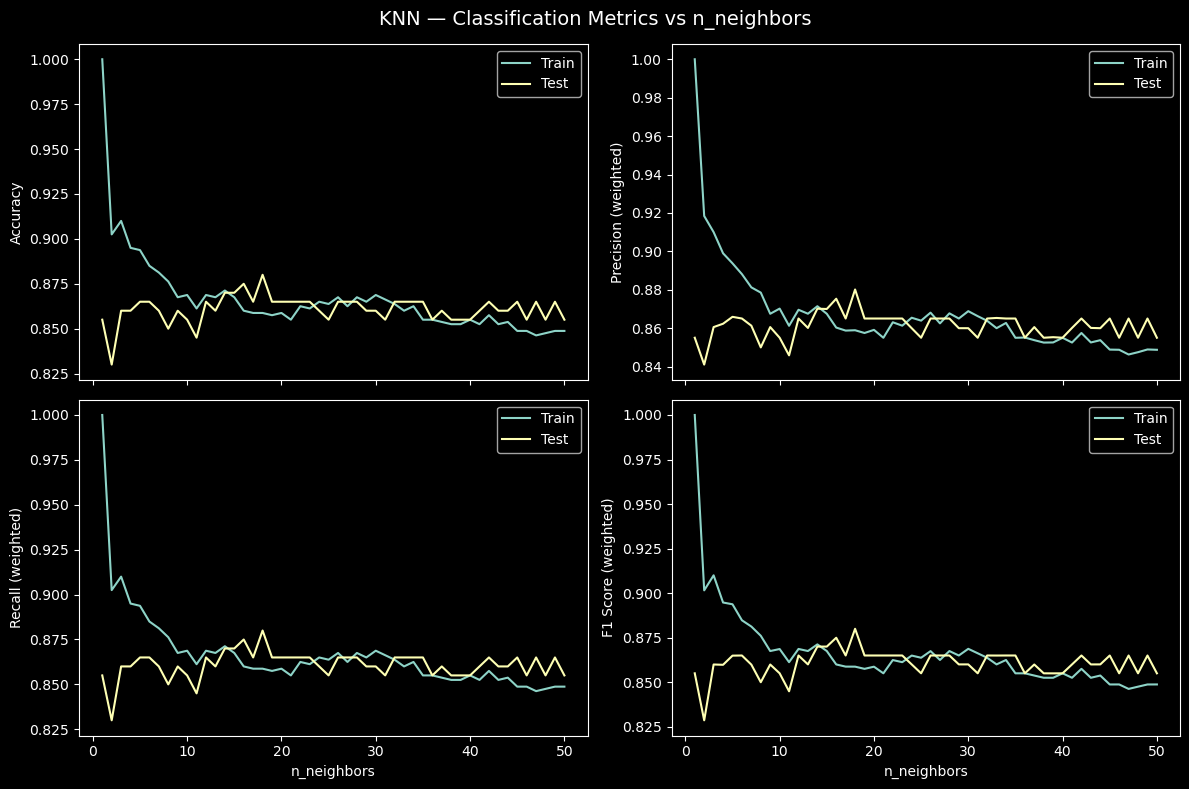

In [10]:
param_values = list(range(1, 51))  # n_neighbors: 1 to 50
train_acc, train_pre, train_rec, train_f1 = [], [], [], []
test_acc,  test_pre,  test_rec,  test_f1  = [], [], [], []

for k in param_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    for X_s, y_s, acc_l, pre_l, rec_l, f1_l in [
        (X_train, y_train, train_acc, train_pre, train_rec, train_f1),
        (X_test,  y_test,  test_acc,  test_pre,  test_rec,  test_f1),
    ]:
        y_pred = m.predict(X_s)
        acc_l.append(accuracy_score(y_s, y_pred))
        pre_l.append(precision_score(y_s, y_pred, average='weighted', zero_division=0))
        rec_l.append(recall_score(y_s, y_pred, average='weighted', zero_division=0))
        f1_l.append(f1_score(y_s, y_pred, average='weighted', zero_division=0))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metric_labels = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 Score (weighted)']
train_metrics  = [train_acc, train_pre, train_rec, train_f1]
test_metrics   = [test_acc,  test_pre,  test_rec,  test_f1]

for ax, label, tr, te in zip(axes.flat, metric_labels, train_metrics, test_metrics):
    ax.plot(param_values, tr, label='Train')
    ax.plot(param_values, te, label='Test')
    ax.set_ylabel(label)
    ax.legend()

for ax in axes[1]:
    ax.set_xlabel('n_neighbors')

fig.suptitle('KNN — Classification Metrics vs n_neighbors', fontsize=14)
plt.tight_layout()
plt.show()

---
## Decision Tree

A Decision Tree partitions the feature space into rectangular regions using a hierarchy of if/else rules learned from the training data. The `max_leaf_nodes` parameter limits how many terminal regions the tree can create — effectively capping its complexity.

- **Few leaf nodes (e.g., 2–3):** The tree makes only a handful of splits — simple, interpretable, but may underfit.
- **Many leaf nodes (e.g., 30+):** The tree carves the space very finely — capable of capturing complex patterns, but risks memorizing the training data.

One key property: Decision Trees are **deterministic** (given the same data and settings, you get the same tree every time), so there is no randomness in this sweep — each curve is smooth and reproducible.

We sweep `max_leaf_nodes` from **2 to 50** (all integers).

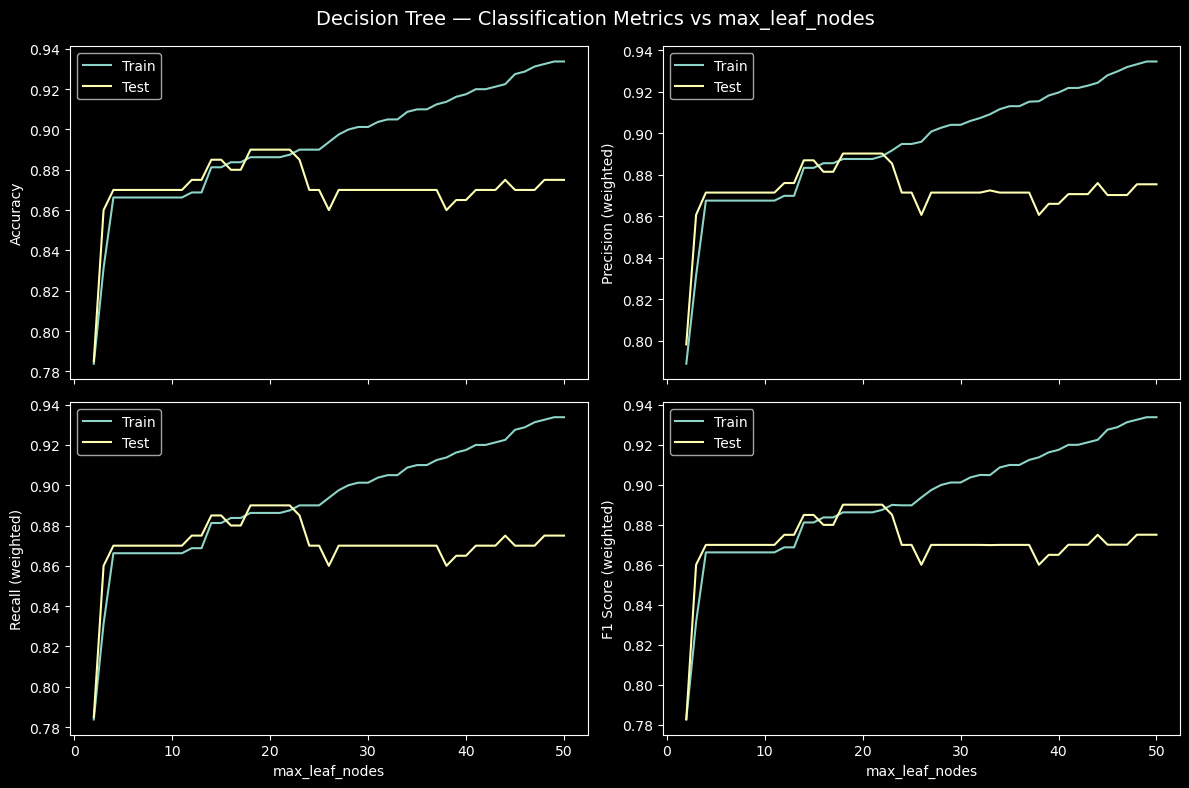

In [11]:
param_values = list(range(2, 51))  # max_leaf_nodes: 2 to 50
train_acc, train_pre, train_rec, train_f1 = [], [], [], []
test_acc,  test_pre,  test_rec,  test_f1  = [], [], [], []

for v in param_values:
    m = DecisionTreeClassifier(max_leaf_nodes=v)
    m.fit(X_train, y_train)
    for X_s, y_s, acc_l, pre_l, rec_l, f1_l in [
        (X_train, y_train, train_acc, train_pre, train_rec, train_f1),
        (X_test,  y_test,  test_acc,  test_pre,  test_rec,  test_f1),
    ]:
        y_pred = m.predict(X_s)
        acc_l.append(accuracy_score(y_s, y_pred))
        pre_l.append(precision_score(y_s, y_pred, average='weighted', zero_division=0))
        rec_l.append(recall_score(y_s, y_pred, average='weighted', zero_division=0))
        f1_l.append(f1_score(y_s, y_pred, average='weighted', zero_division=0))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metric_labels = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 Score (weighted)']
train_metrics  = [train_acc, train_pre, train_rec, train_f1]
test_metrics   = [test_acc,  test_pre,  test_rec,  test_f1]

for ax, label, tr, te in zip(axes.flat, metric_labels, train_metrics, test_metrics):
    ax.plot(param_values, tr, label='Train')
    ax.plot(param_values, te, label='Test')
    ax.set_ylabel(label)
    ax.legend()

for ax in axes[1]:
    ax.set_xlabel('max_leaf_nodes')

fig.suptitle('Decision Tree — Classification Metrics vs max_leaf_nodes', fontsize=14)
plt.tight_layout()
plt.show()

---
## Random Forest

A Random Forest builds many independent Decision Trees, each trained on a **bootstrap sample** of the training data with a random subset of features considered at each split. The final prediction is the **majority vote** across all trees.

The key hyperparameter is `n_estimators` — the number of trees in the forest:

- **Few trees (e.g., 1–5):** The ensemble is small and noisy — results vary run to run because any single tree has high variance.
- **Many trees (e.g., 50+):** Averaging over more trees reduces variance and the ensemble stabilizes.

An important difference from KNN and Decision Trees: **adding more trees almost never hurts** test performance — it just converges. `n_estimators` is more of a computational budget than a complexity dial. You rarely need more than 100–200 trees on a dataset this size.

We sweep from **1 to 100** trees (all integers).

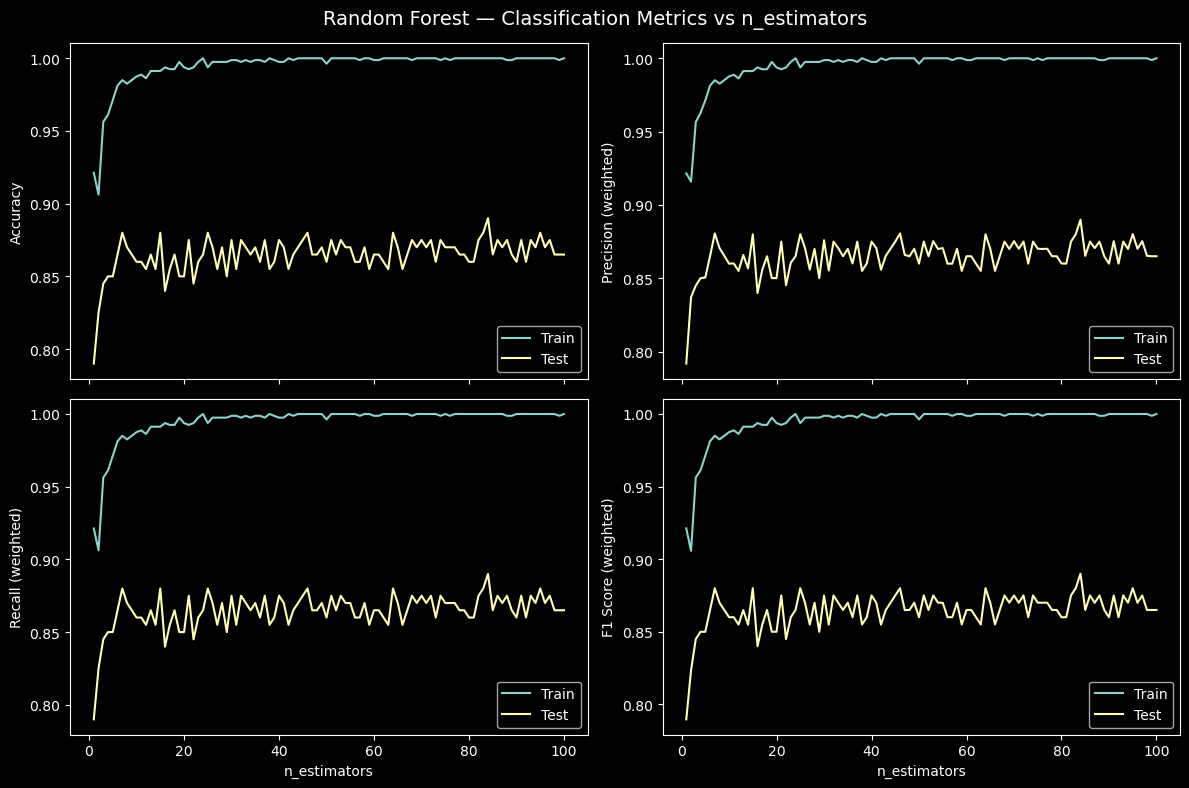

In [12]:
param_values = list(range(1, 101))  # n_estimators: 1 to 100
train_acc, train_pre, train_rec, train_f1 = [], [], [], []
test_acc,  test_pre,  test_rec,  test_f1  = [], [], [], []

for v in param_values:
    m = RandomForestClassifier(n_estimators=v)
    m.fit(X_train, y_train)
    for X_s, y_s, acc_l, pre_l, rec_l, f1_l in [
        (X_train, y_train, train_acc, train_pre, train_rec, train_f1),
        (X_test,  y_test,  test_acc,  test_pre,  test_rec,  test_f1),
    ]:
        y_pred = m.predict(X_s)
        acc_l.append(accuracy_score(y_s, y_pred))
        pre_l.append(precision_score(y_s, y_pred, average='weighted', zero_division=0))
        rec_l.append(recall_score(y_s, y_pred, average='weighted', zero_division=0))
        f1_l.append(f1_score(y_s, y_pred, average='weighted', zero_division=0))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metric_labels = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 Score (weighted)']
train_metrics  = [train_acc, train_pre, train_rec, train_f1]
test_metrics   = [test_acc,  test_pre,  test_rec,  test_f1]

for ax, label, tr, te in zip(axes.flat, metric_labels, train_metrics, test_metrics):
    ax.plot(param_values, tr, label='Train')
    ax.plot(param_values, te, label='Test')
    ax.set_ylabel(label)
    ax.legend()

for ax in axes[1]:
    ax.set_xlabel('n_estimators')

fig.suptitle('Random Forest — Classification Metrics vs n_estimators', fontsize=14)
plt.tight_layout()
plt.show()